<a href="https://colab.research.google.com/github/csargin/stylization/blob/main/stylization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import tensorflow as tf
import tensorflow_hub as hub

from PIL import Image
import numpy as np


In [19]:
model = hub.load("https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2")

In [20]:
def load_image(img_path, max_dim):
    img = Image.open(img_path).convert("RGB")
    img.thumbnail((max_dim, max_dim))
    arr=np.array(img)/255.0
    return tf.expand_dims(arr.astype(np.float32), axis = 0)

In [37]:
def stylize(content_path, style_path, content_max=512,style_max=256):
    content= load_image(content_path, content_max)
    style= load_image(style_path, style_max)
    outputs = model(tf.constant(content), tf.constant(style))
    stylized = outputs[0][0].numpy()
    stylized = (stylized * 255).clip(0,255).astype(np.uint8)
    return Image.fromarray(stylized)


In [32]:
from google.colab import files
uploaded = files.upload()
content_path = list(uploaded.keys())[0]

Saving optimus.jpeg to optimus (3).jpeg


In [34]:
from google.colab import files
uploaded = files.upload()
style_path = list(uploaded.keys())[0]

Saving 1.png to 1 (1).png


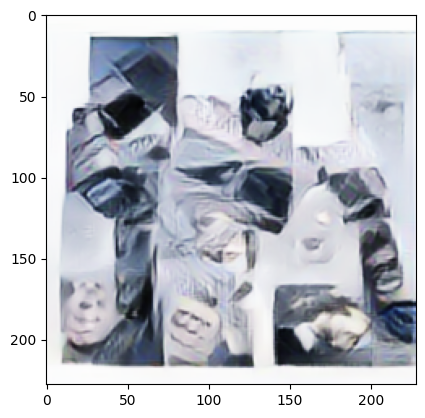

In [38]:
import matplotlib.pyplot as plt
result = stylize(content_path, style_path)
plt.imshow(result)

In [36]:
result.save("result.jpg")
files.download("result.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>